# Compare training and enzyme explorer plots across runs

Set run folders in the next cell. The notebook re-plots validation metrics from each run's `train.log`.

It also compares shared PNG plots in `enzyme_explorer_validation` across runs (for example boxplot, violin, and threshold-count plots).

In [43]:
from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt
from IPython.display import Markdown, display

workspace_root = Path.cwd()
plot_module_dir = workspace_root / "plot" if (workspace_root / "plot").exists() else workspace_root
if str(plot_module_dir) not in sys.path:
    sys.path.insert(0, str(plot_module_dir))

import training_metrics
importlib.reload(training_metrics)
find_shared_pngs = training_metrics.find_shared_pngs
plot_metric_comparison = training_metrics.plot_metric_comparison
plot_png_comparison = training_metrics.plot_png_comparison

runs = [
    "/Volumes/data/Users/Matous/terpene_synthases/output/dplm/training/TPS_dplm_150m_stage3_grid_lr1em3_wu2000_lend0p0001_winit1em06",
    "/Volumes/data/Users/Matous/terpene_synthases/output/dplm/training/TPS_dplm_150m_stage3_grid_lr1em4_wu2000_lend1em05_winit1em07",
    "/Volumes/data/Users/Matous/terpene_synthases/output/dplm/training/TPS_dplm_150m_stage3_grid_lr1em5_wu2000_lend1em06_winit1em08",
    "/Volumes/data/Users/Matous/terpene_synthases/output/dplm/training/TPS_dplm_150m_stage3_grid_lr1em3_wu2000_lend0p0001_winit1em06_loratrue",
    "/Volumes/data/Users/Matous/terpene_synthases/output/dplm/training/TPS_dplm_150m_stage3_grid_lr1em4_wu2000_lend1em05_winit1em07_loratrue",
    "/Volumes/data/Users/Matous/terpene_synthases/output/dplm/training/TPS_dplm_150m_stage3_grid_lr1em5_wu2000_lend1em06_winit1em08_loratrue",
]

metrics_to_plot = [
    "loss",
    "nll_loss",
    "ppl",
    "ppl_best",
    "acc",
    "acc_best",
]
enzyme_plot_subdir = "enzyme_explorer_validation"

x_axis = "global_steps"
ncols = 3
shared_y_axis = True
max_title_length = 140
title_wrap_width = 48
title_max_lines = 2

# Layout for metric line plots
width_per_col = 6.4
height_per_row = 4.6
wspace = 0.28
hspace = 0.62

# Larger and tighter layout for enzyme image comparisons
enzyme_width_per_col = 7.4
enzyme_height_per_row = 5.2
enzyme_wspace = 0.12
enzyme_hspace = 0.32

## val/loss

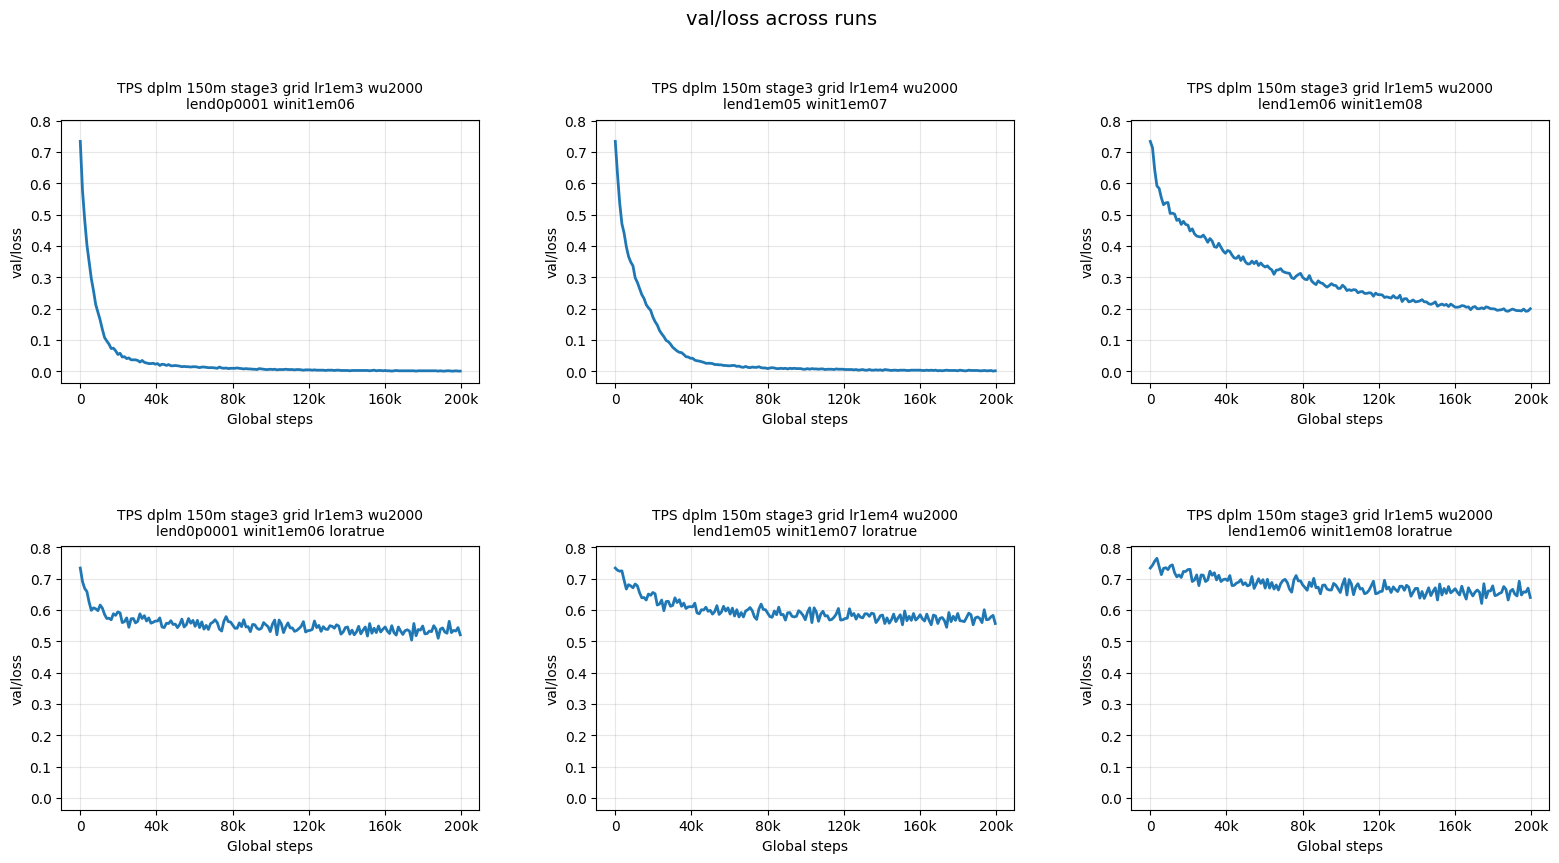

## val/nll_loss

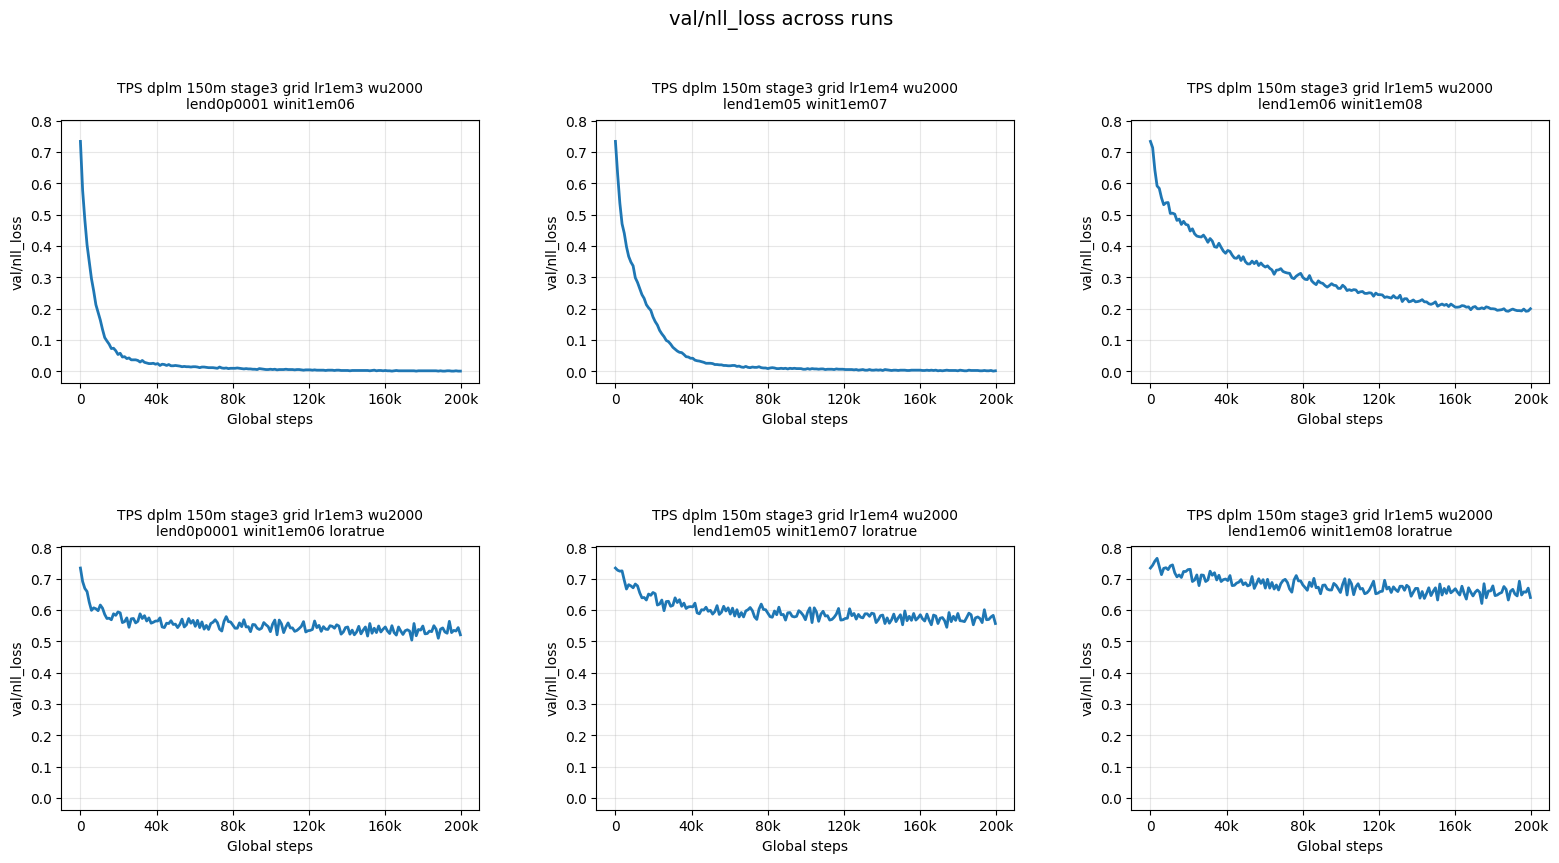

## val/ppl

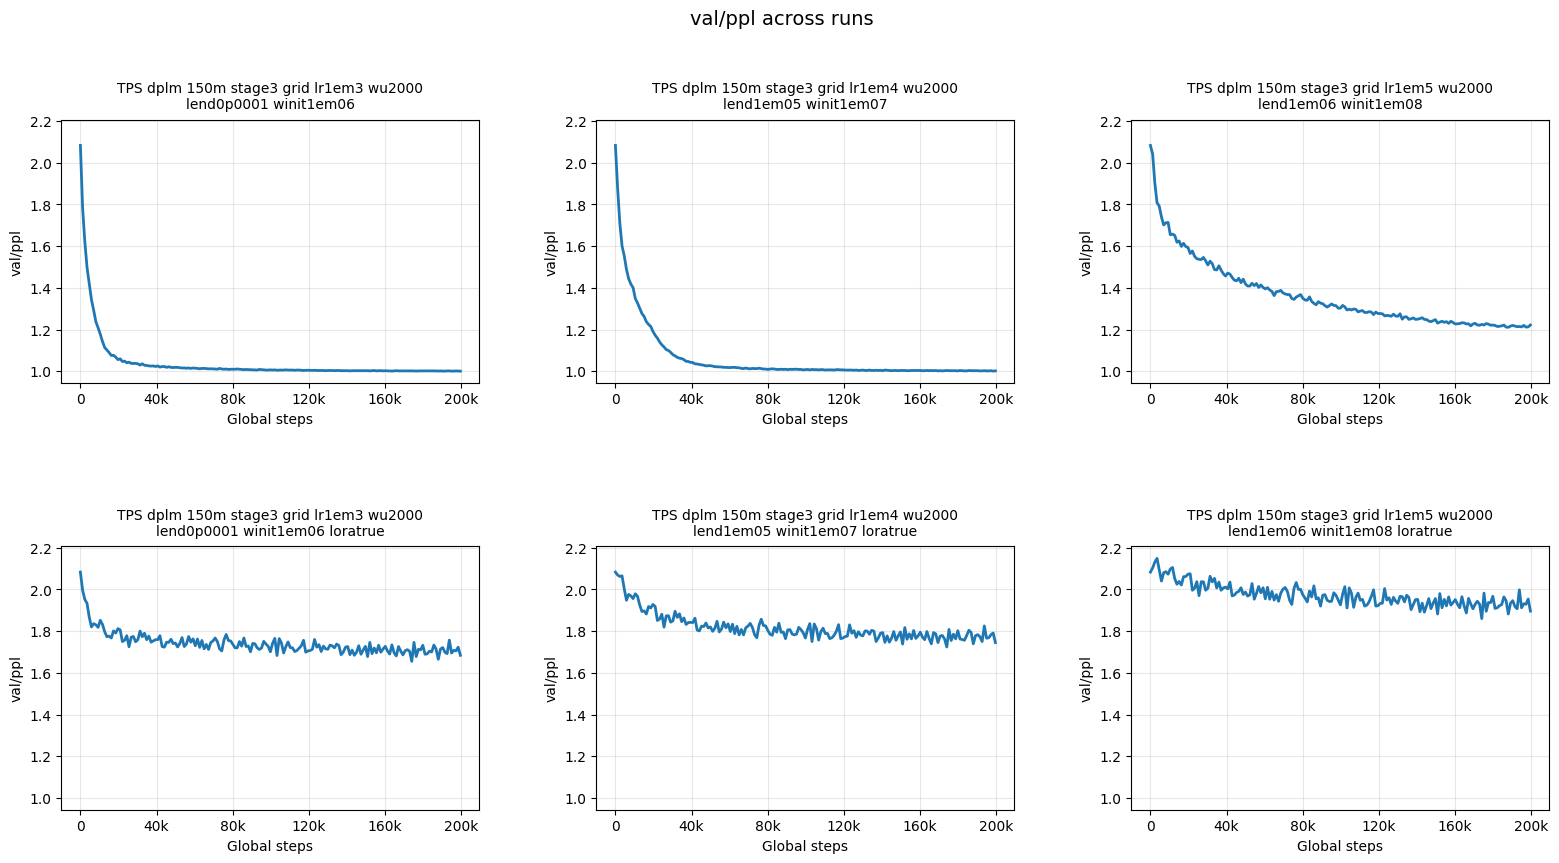

## val/ppl_best

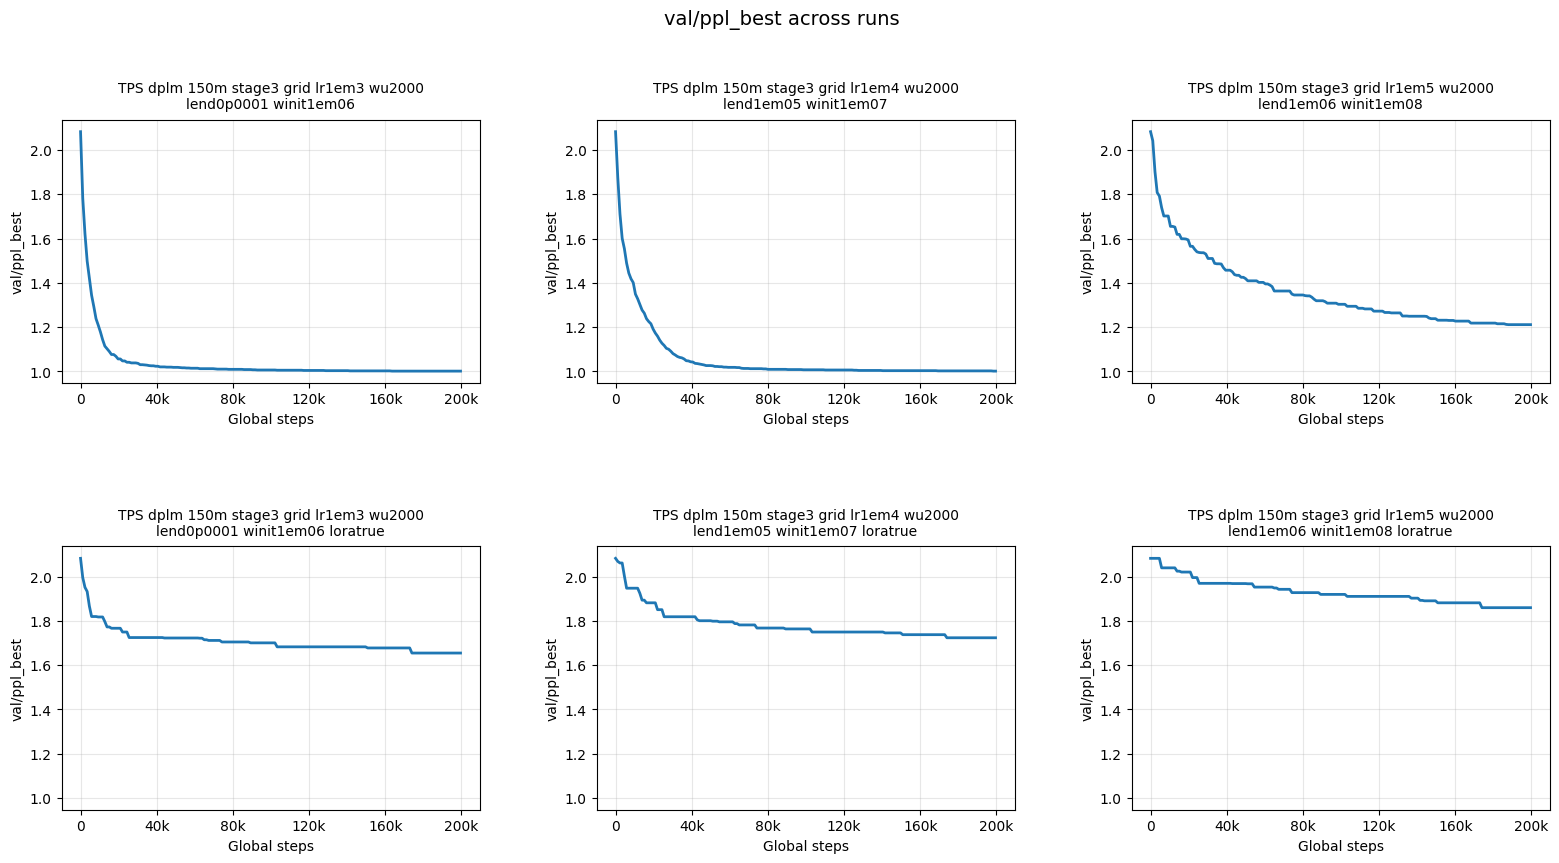

## val/acc

Skipping metric `acc`: "Metric 'val/acc' not found in /Volumes/data/Users/Matous/terpene_synthases/output/dplm/training/TPS_dplm_150m_stage3_grid_lr1em3_wu2000_lend0p0001_winit1em06/train.log. Available: ['loss', 'nll_loss', 'ppl', 'ppl_best']"

## val/acc_best

Skipping metric `acc_best`: "Metric 'val/acc_best' not found in /Volumes/data/Users/Matous/terpene_synthases/output/dplm/training/TPS_dplm_150m_stage3_grid_lr1em3_wu2000_lend0p0001_winit1em06/train.log. Available: ['loss', 'nll_loss', 'ppl', 'ppl_best']"

## enzyme_explorer_validation

Found **3** shared PNG files.

### Boxplot

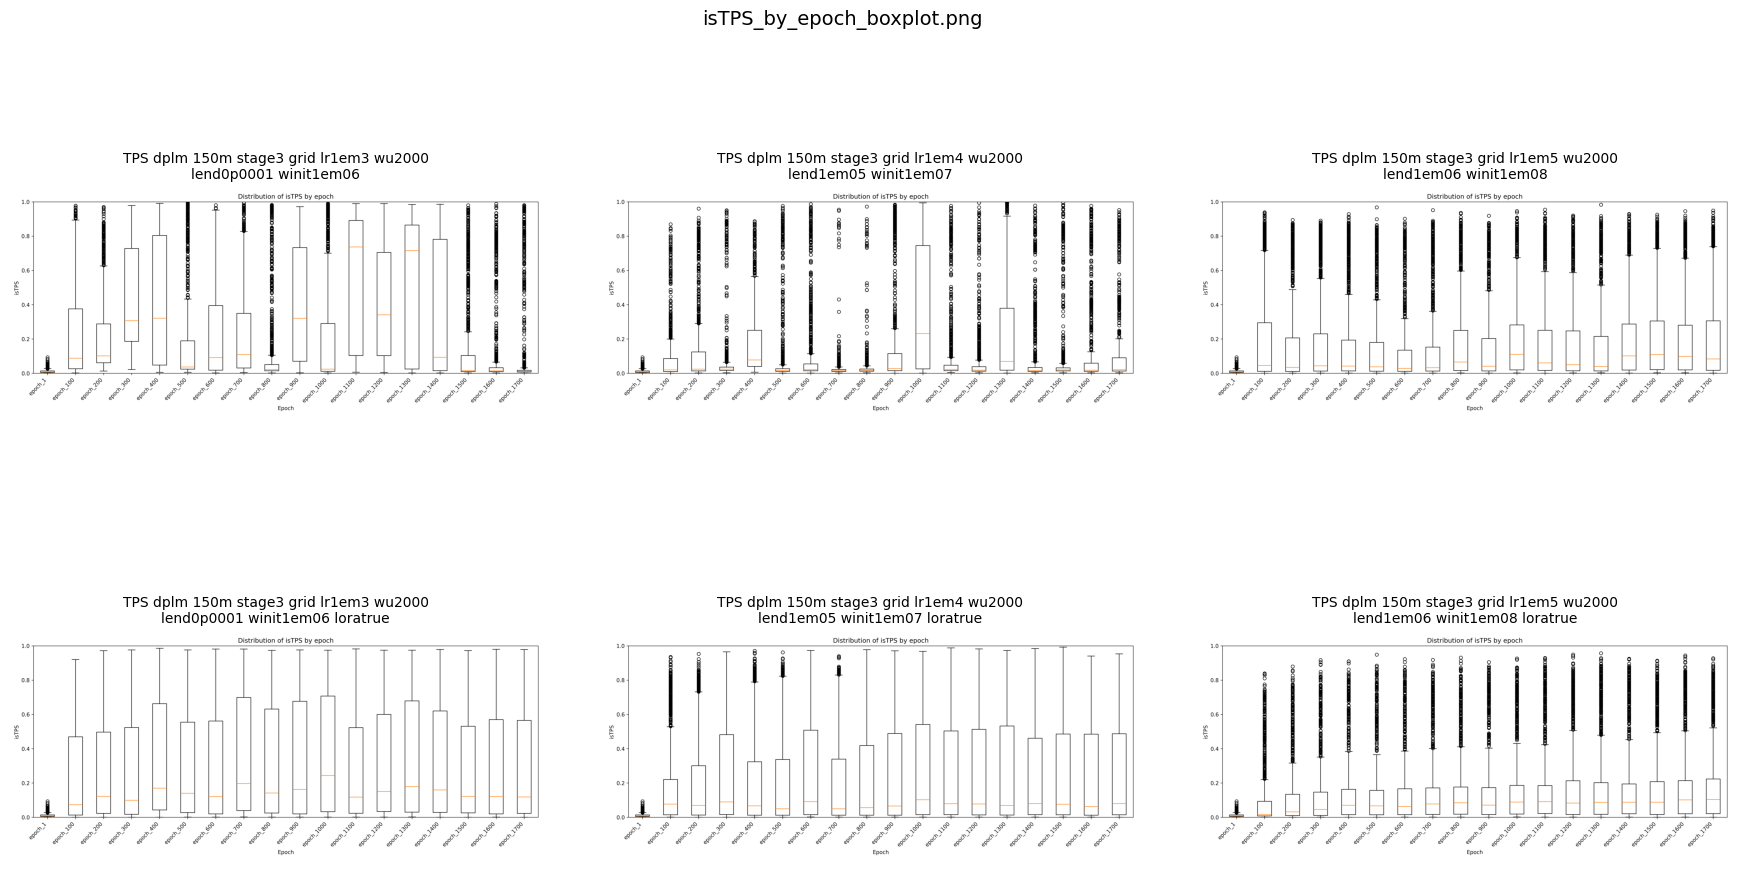

### Counts

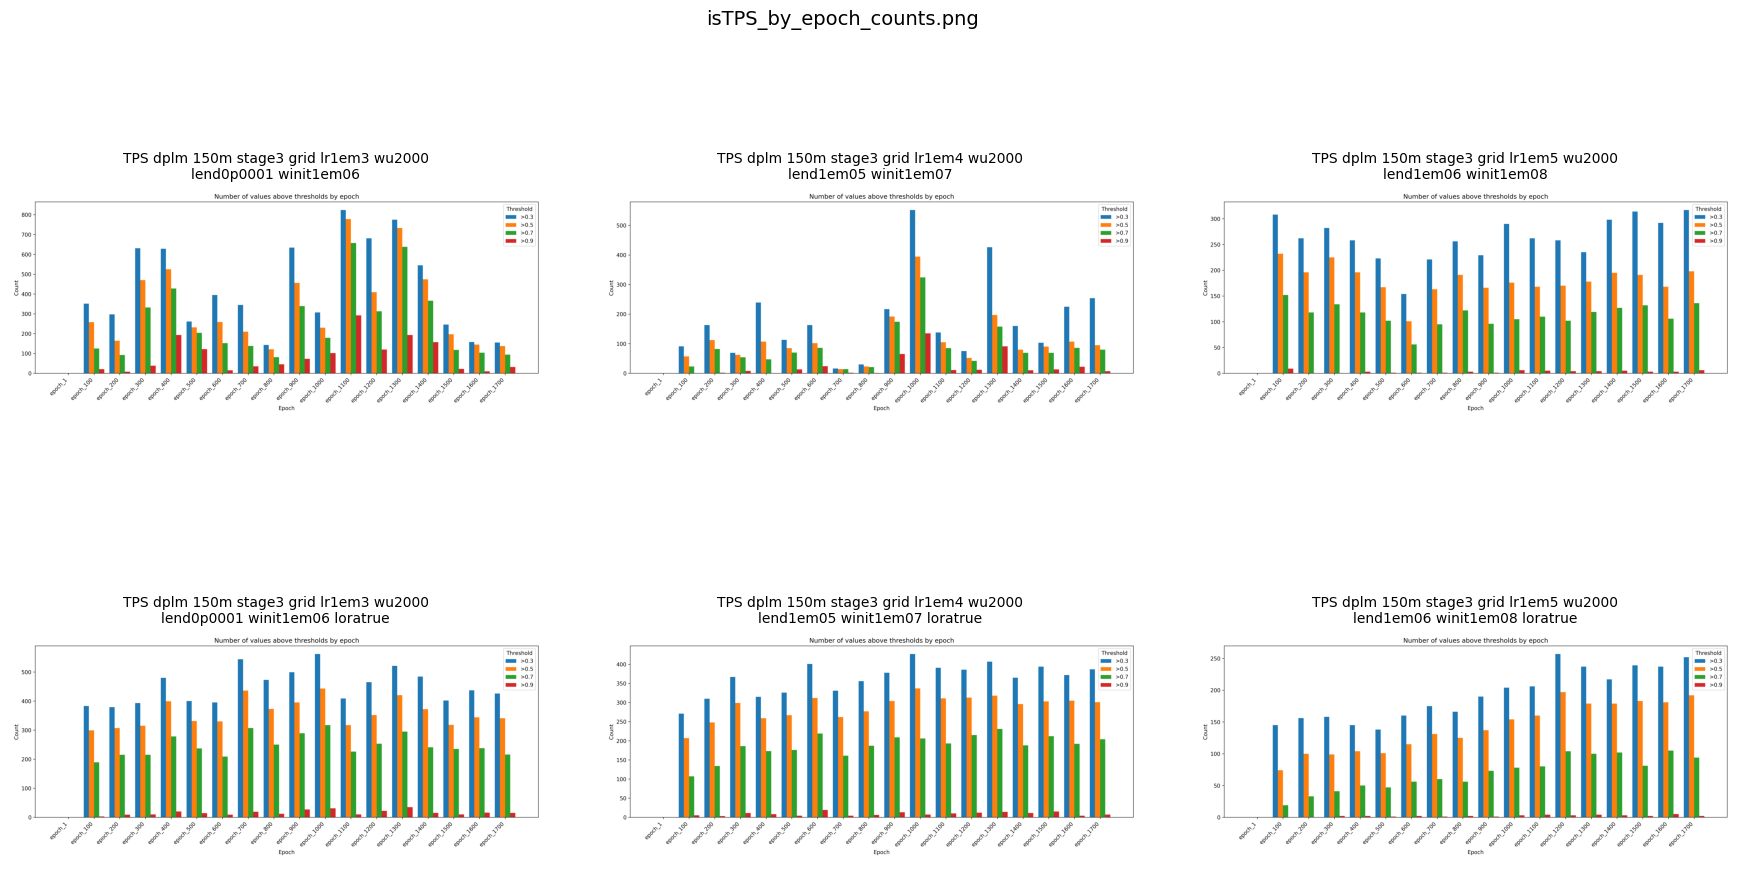

### Violin

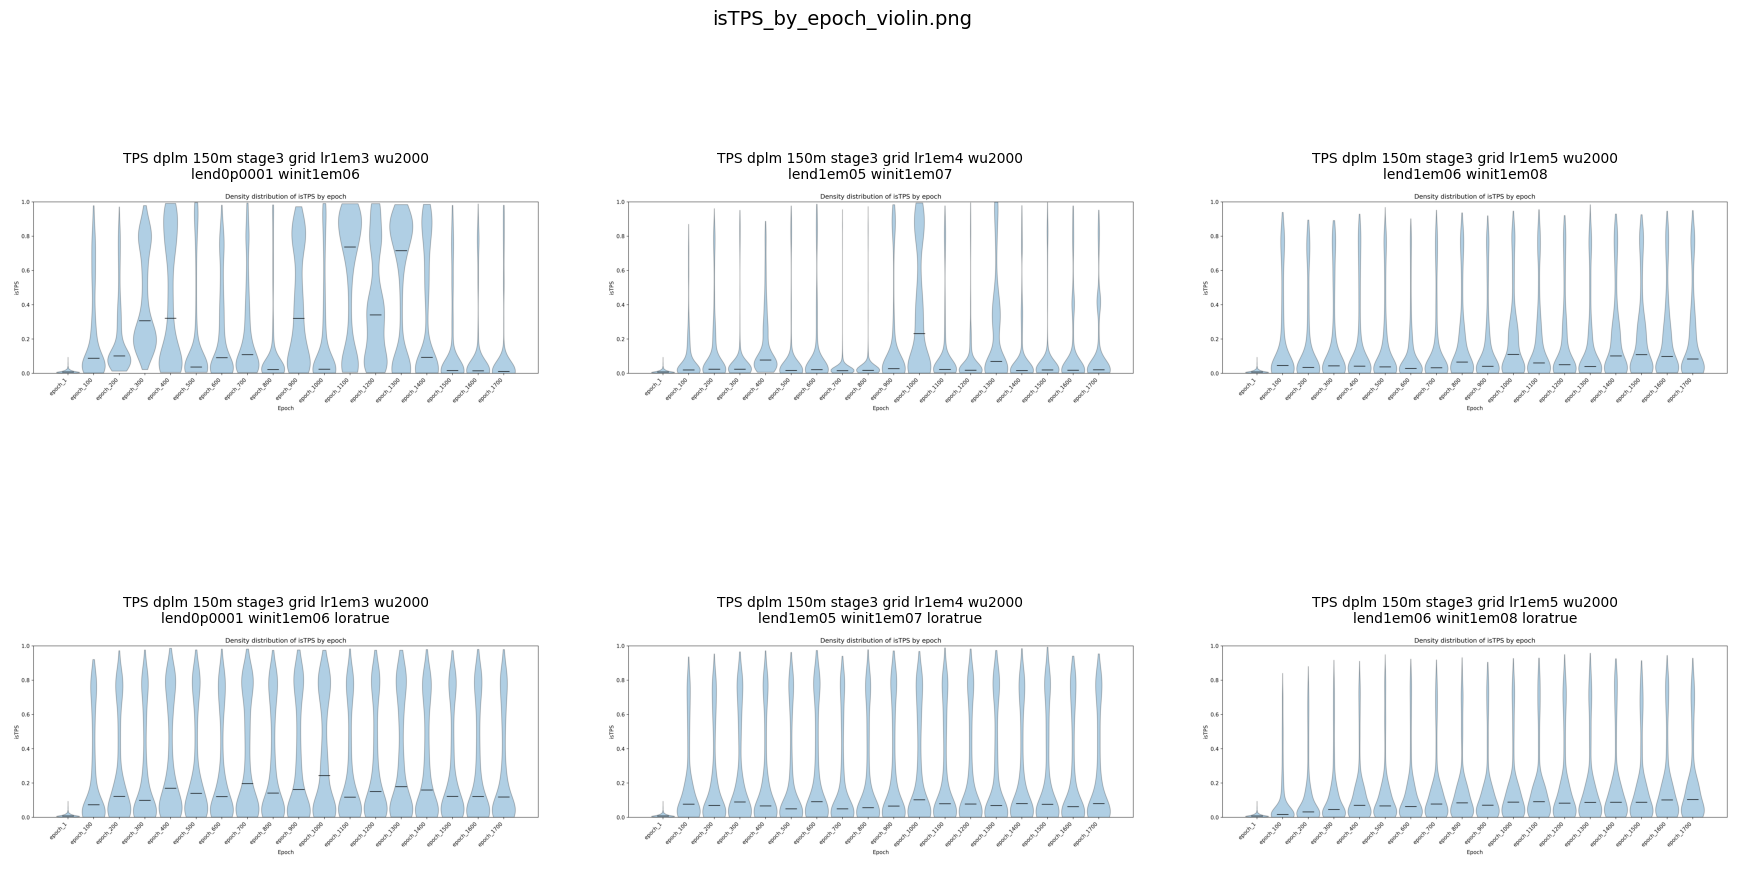

In [44]:
for metric_name in metrics_to_plot:
    display(Markdown(f"## val/{metric_name}"))
    try:
        fig = plot_metric_comparison(
            runs=runs,
            metric_name=metric_name,
            x_axis=x_axis,
            ncols=ncols,
            max_title_length=max_title_length,
            shared_y_axis=shared_y_axis,
            title_wrap_width=title_wrap_width,
            title_max_lines=title_max_lines,
            width_per_col=width_per_col,
            height_per_row=height_per_row,
            wspace=wspace,
            hspace=hspace,
        )
        display(fig)
        plt.close(fig)
    except KeyError as error:
        display(Markdown(f"Skipping metric `{metric_name}`: {error}"))

display(Markdown(f"## {enzyme_plot_subdir}"))
try:
    shared_pngs = find_shared_pngs(runs, enzyme_plot_subdir)
    if not shared_pngs:
        display(Markdown("No shared PNG files found in enzyme_explorer_validation."))
    else:
        display(Markdown(f"Found **{len(shared_pngs)}** shared PNG files."))
        for relative_png in shared_pngs:
            stem = relative_png.stem.lower()
            if "boxplot" in stem:
                short_header = "### Boxplot"
            elif "counts" in stem:
                short_header = "### Counts"
            elif "violin" in stem:
                short_header = "### Violin"
            else:
                short_header = f"### {relative_png.stem}"
            display(Markdown(short_header))

            fig = plot_png_comparison(
                runs=runs,
                plot_subdir=enzyme_plot_subdir,
                relative_png_path=relative_png,
                ncols=ncols,
                max_title_length=max_title_length,
                title_wrap_width=title_wrap_width,
                title_max_lines=title_max_lines,
                width_per_col=enzyme_width_per_col,
                height_per_row=enzyme_height_per_row,
                wspace=enzyme_wspace,
                hspace=enzyme_hspace,
            )
            display(fig)
            plt.close(fig)
except FileNotFoundError as error:
    display(Markdown(f"Skipping enzyme_explorer_validation comparison: {error}"))